<a href="https://colab.research.google.com/github/imperorrp/discrete-generative-models-proj-1/blob/main/notebooks/runs/tc_lora_cifar_run3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TC-LoRA on CIFAR-100 images

Baseline 1 of 3. Trains a base diffusion model, freezes it, trains a TC-LoRA
hypernetwork on top, samples from both.

**Paper:** Cho, Ohana, Jacobsen, Jothi, Chen, Mao, Can.
*TC-LoRA: Temporally Modulated Conditional LoRA for Adaptive Diffusion Control.*
NeurIPS 2025 SpaVLE workshop. [arXiv:2510.09561](https://arxiv.org/abs/2510.09561)

**The authors released no code** (checked 2026-09-28). `src/guidance/baselines/tc_lora.py`
is our reimplementation from Eq. 1 and Appendices A-B; its header lists every deviation.
Report this as a reimplementation, not as their result reproduced.

**Label path.** Runs 1 and 2 gave the frozen backbone the true class label *and* gave the
hypernetwork a text embedding of the class name. Those carry the same information, so the
adapter had nothing to add (`docs/findings.md`). By default the backbone now sees the
**null label** and the text, through the adapter, is the only route to the class. Set
`label_path = True` to reproduce the run-2 setting. The cross-attention notebook uses the
same switch, so the two arms compare directly.

Run top to bottom. On Colab set **Runtime > Change runtime type > GPU** first. If you have
`base.pt` from an earlier run, upload it to the session first and base training is skipped.

In [1]:
# Colab bootstrap. Run once.
import importlib.util, subprocess, sys, os

for pkg in ("transformers", "datasets"):
    if importlib.util.find_spec(pkg) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

if importlib.util.find_spec("guidance") is None:
    if not os.path.exists("discrete-generative-models-proj-1"):
        subprocess.run(["git", "clone", "-q",
                        "https://github.com/imperorrp/discrete-generative-models-proj-1.git"],
                       check=True)
    sys.path.insert(0, "discrete-generative-models-proj-1/src")

import torch
from guidance.baselines.tc_lora import TCLoRA

# Record which commit of the code this run used. Goes into the manifest and the
# saved outputs, so two executed notebooks can be diffed by commit.
def _git_sha():
    for d in ("discrete-generative-models-proj-1", "."):
        try:
            return subprocess.check_output(["git", "-C", d, "rev-parse", "--short", "HEAD"],
                                           text=True, stderr=subprocess.DEVNULL).strip()
        except Exception:
            pass
    return "unknown"

GIT_SHA = _git_sha()
print("code version:", GIT_SHA)
print("device:", "cuda" if torch.cuda.is_available()
      else "CPU  <-- Runtime > Change runtime type > GPU")

code version: 1aff1df
device: cuda


## Data source

You do not need to do anything here. The loader tries, in order:

1. a local copy -- `./cifar`, `/content/cifar`, `/content/drive/MyDrive/cifar`, and a few
   others, each expected to contain a `cifar-100-python` folder
2. the **HuggingFace CDN**, which takes seconds

It never touches `www.cs.toronto.edu/~kriz/`, torchvision's default, which is
rate-limited to roughly 50 kB/s and takes most of an hour for 169 MB.

If you do want to use a Drive copy, mount Drive with the **folder icon in the left
sidebar, then the Mount Drive button**. Calling `drive.mount()` from a code cell often
fails with `MessageError` when the browser blocks third-party cookies; the sidebar button
handles the auth flow properly.

## Config

In [2]:
import math, time, json
from dataclasses import dataclass, asdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

@dataclass
class Cfg:
    seed: int = 10          # training randomness
    split_seed: int = 10    # validation split; fixed so multi-seed runs share one split
    batch_size: int = 64
    base_epochs: int = 30
    lora_epochs: int = 15
    lr_base: float = 2e-4
    lr_hyper: float = 1e-4
    K: int = 1000                  # diffusion training steps
    sample_steps: int = 50         # DDIM steps
    rank: int = 4
    hyper_width: int = 256
    label_path: bool = False       # False: backbone sees the null label; text is the only condition
    reuse_base: bool = True        # load base.pt if present instead of retraining
    limit: int = 0                 # >0 truncates the training set, for smoke tests

cfg = Cfg()
DEV = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(cfg.seed); np.random.seed(cfg.seed)
print(DEV, asdict(cfg))

cuda {'seed': 10, 'split_seed': 10, 'batch_size': 64, 'base_epochs': 30, 'lora_epochs': 15, 'lr_base': 0.0002, 'lr_hyper': 0.0001, 'K': 1000, 'sample_steps': 50, 'rank': 4, 'hyper_width': 256, 'label_path': False, 'reuse_base': True, 'limit': 0}


## Data

From `src/guidance/data/cifar.py`. Pixels normalised to `[-1, 1]`; 50 images per class
held out for validation with a seeded per-class shuffle, so both splits see all 100
classes.

In [3]:
from guidance.data.cifar import make_loaders

train_loader, val_loader, meta = make_loaders(
    batch_size=cfg.batch_size, seed=cfg.split_seed, limit=cfg.limit)

xb, cb = next(iter(train_loader))
print("x", tuple(xb.shape), f"[{float(xb.min()):.2f}, {float(xb.max()):.2f}]",
      "| cond", tuple(cb.shape))
print("train batches", len(train_loader), "| val batches", len(val_loader))
print("conditions", meta["n_conditions"], "| example text:", meta["cond_text"][0])

no local copy found; fetching from the HuggingFace CDN


README.md:   0%|          | 0.00/9.98k [00:00<?, ?B/s]

cifar100/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  119MB            

cifar100/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

cifar100/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 23.8MB            

cifar100/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

x (64, 3, 32, 32) [-1.00, 1.00] | cond (64,)
train batches 703 | val batches 79
conditions 100 | example text: a photo of a apple


## Frozen condition encoder

`h(c)` is a frozen CLIP text embedding of the condition description. Falls back to fixed
random vectors if CLIP will not load, so the notebook still runs — but a fallback run is
**not a result**, and the manifest records it.

In [4]:
def build_cond_embeddings(texts, device):
    try:
        from transformers import CLIPTokenizer, CLIPTextModel
        name = "openai/clip-vit-base-patch32"
        tok = CLIPTokenizer.from_pretrained(name)
        enc = CLIPTextModel.from_pretrained(name).to(device).eval()
        for p in enc.parameters():
            p.requires_grad_(False)
        out = []
        with torch.no_grad():
            for i in range(0, len(texts), 64):
                b = tok(texts[i:i + 64], padding=True, truncation=True, return_tensors="pt")
                out.append(enc(**{k: v.to(device) for k, v in b.items()}).pooler_output)
        emb = torch.cat(out)
        return emb / emb.norm(dim=-1, keepdim=True), False
    except Exception as e:
        print(f"CLIP unavailable ({type(e).__name__}); using random fallback embeddings.")
        g = torch.Generator().manual_seed(0)
        emb = torch.randn(len(texts), 512, generator=g)
        return (emb / emb.norm(dim=-1, keepdim=True)).to(device), True

COND_EMB, IS_FALLBACK = build_cond_embeddings(meta["cond_text"], DEV)
COND_DIM = COND_EMB.shape[1]
print("condition embeddings:", tuple(COND_EMB.shape), "| fallback:", IS_FALLBACK)

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

...

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[transformers] CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_projection.weight                                         | UNEXPECTED |  | 
vision_model.encoder.l

condition embeddings: (100, 512) | fallback: False


## Backbone

In [5]:
def timestep_embedding(t, dim):
    half = dim // 2
    freqs = torch.exp(-math.log(10_000.0) * torch.arange(half, device=t.device) / half)
    args = t.float()[:, None] * freqs[None, :]
    return torch.cat([args.cos(), args.sin()], dim=-1)


def conv_block(cin, cout, groups=8):
    return nn.Sequential(
        nn.Conv2d(cin, cout, 3, padding=1), nn.GroupNorm(groups, cout), nn.SiLU(),
        nn.Conv2d(cout, cout, 3, padding=1), nn.GroupNorm(groups, cout), nn.SiLU(),
    )


class UNet(nn.Module):
    '''Class-conditional U-Net. The label enters as a per-channel bias after block 1.'''

    def __init__(self, c=64, n_classes=100, tdim=128):
        super().__init__()
        self.tdim, self.null = tdim, n_classes
        self.t_mlp = nn.Sequential(nn.Linear(tdim, c), nn.SiLU(), nn.Linear(c, c))
        self.label = nn.Embedding(n_classes + 1, c)      # +1 = null token
        self.e1, self.e2 = conv_block(3, c), conv_block(c, 2 * c)
        self.mid = conv_block(2 * c, 4 * c)
        self.d2, self.d1 = conv_block(6 * c, 2 * c), conv_block(3 * c, c)
        self.out = nn.Conv2d(c, 3, 1)
        self.pool = nn.MaxPool2d(2)
        nn.init.zeros_(self.out.weight); nn.init.zeros_(self.out.bias)

    def forward(self, x, t, cond_ids=None):
        if cond_ids is None:
            cond_ids = torch.full((x.shape[0],), self.null, device=x.device, dtype=torch.long)
        bias = (self.t_mlp(timestep_embedding(t, self.tdim))
                + self.label(cond_ids))[:, :, None, None]
        s1 = self.e1(x) + bias
        s2 = self.e2(self.pool(s1))
        h = self.mid(self.pool(s2))
        h = self.d2(torch.cat([F.interpolate(h, size=s2.shape[-2:]), s2], 1))
        h = self.d1(torch.cat([F.interpolate(h, size=s1.shape[-2:]), s1], 1))
        return self.out(h)


def make_backbone():
    return UNet(64, meta["n_conditions"])

torch.manual_seed(cfg.seed)      # model init and training randomness follow `seed`, not the split
net = make_backbone().to(DEV)
print(f"backbone params: {sum(p.numel() for p in net.parameters()):,}")

backbone params: 1,904,707


## Diffusion — cosine schedule, epsilon prediction, DDIM sampler

In [6]:
def cosine_alpha_bar(K, s=0.008, device="cpu"):
    steps = torch.arange(K + 1, dtype=torch.float32, device=device) / K
    f = torch.cos((steps + s) / (1 + s) * math.pi / 2) ** 2
    return (f / f[0])[1:].clamp(1e-5, 0.9999)

ABAR = cosine_alpha_bar(cfg.K, device=DEV)
NULL_ID = meta["n_conditions"]

# At the first DDIM step sqrt(abar) is about 0.003, so x0 = (x - sqrt(1-abar) eps)/sqrt(abar)
# divides by a tiny number and any error in eps is amplified ~300x. Without clamping the
# samples blow up and the variance ratio reads in the thousands. Images are normalised to
# [-1, 1]; for standardised cell data the clamp is the training range.
CLIP_X0 = 1.0 if len(meta["shape"]) == 3 else float(
    torch.cat([x for x, _ in train_loader]).abs().max())
print("x0 clamp:", round(CLIP_X0, 3))


def add_noise(x0, gen=None):
    '''gen: pass a seeded torch.Generator to get the same (k, eps) every call.'''
    n = x0.shape[0]
    k = torch.randint(0, cfg.K, (n,), device=x0.device, generator=gen)
    eps = torch.randn(x0.shape, device=x0.device, generator=gen)
    ab = ABAR[k].view(n, *([1] * (x0.dim() - 1)))
    return ab.sqrt() * x0 + (1 - ab).sqrt() * eps, k, eps


def drop_labels(y, p_drop=0.1):
    '''Condition dropout creates the null branch that guidance needs later.'''
    keep = torch.rand(y.shape[0], device=y.device) >= p_drop
    return torch.where(keep, y, torch.full_like(y, NULL_ID))


@torch.no_grad()
def ddim_sample(eps_fn, n, shape, steps, clip_x0=None, n_snapshots=0, x_init=None):
    '''eps_fn(x, t) -> predicted noise. Deterministic DDIM.

    Convention, shared by every arm in this project: clip the predicted x0, then recompute
    eps from the clipped x0 before stepping (as TFG's official sampler does). Keeping the
    original eps is a different update whenever the clamp engages.

    x_init: pass the same starting noise to two calls for a paired comparison.
    n_snapshots > 0 also returns that many evenly spaced intermediate states, for the
    denoising-trajectory figure.
    '''
    clip_x0 = CLIP_X0 if clip_x0 is None else clip_x0
    idx = torch.linspace(cfg.K - 1, 0, steps).long().to(DEV)
    keep = set(torch.linspace(0, steps - 1, max(n_snapshots, 1)).long().tolist())
    x = torch.randn(n, *shape, device=DEV) if x_init is None else x_init.clone()
    snaps = [x.cpu().clone()] if n_snapshots else []
    for i, k in enumerate(idx):
        t = (k.float() / cfg.K).repeat(n)
        eps = eps_fn(x, t)
        ab = ABAR[k]
        ab_prev = ABAR[idx[i + 1]] if i + 1 < len(idx) else torch.ones_like(ab)
        x0 = ((x - (1 - ab).sqrt() * eps) / ab.sqrt()).clamp(-clip_x0, clip_x0)
        eps = (x - ab.sqrt() * x0) / (1 - ab).sqrt()          # recompute from the clipped x0
        x = ab_prev.sqrt() * x0 + (1 - ab_prev).sqrt() * eps
        if n_snapshots and i in keep:
            snaps.append(x.cpu().clone())
    return (x, snaps) if n_snapshots else x

x0 clamp: 1.0


## Base model — train, or load `base.pt` if it is already here

If `base.pt` from an earlier run is in the session, this cell loads it instead of
retraining, after checking it was trained under the same split, schedule and backbone. The
cross-attention notebook does the same, so both arms can share one frozen base.

Training and validation use **different** loss functions on purpose. Training applies 10%
label dropout so the null branch exists (and so the label-off setting is in-distribution for
the frozen model). Validation does not: it scores the model on the same fixed noise and
timesteps every epoch. The TC-LoRA arm is validated the same way. Without this, the base
model's validation number would include 10% harder unconditional predictions and the TC-LoRA
number would not, and the two would not be comparable. Run 1 had exactly that flaw.

In [7]:
VAL_SEED = cfg.seed + 999


def run_epochs(model, params, n_epochs, lr, tag, train_fn, val_fn, ckpt):
    '''Trains with train_fn, validates with val_fn on fixed noise, keeps the best checkpoint.'''
    opt = torch.optim.AdamW(params, lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(n_epochs, 1))
    hist, best, best_ep = [], float("inf"), 0
    for ep in range(1, n_epochs + 1):
        model.train(); tot = num = 0; t0 = time.time()
        for x, y in train_loader:
            x, y = x.to(DEV), y.to(DEV)
            loss = train_fn(x, y)
            opt.zero_grad(set_to_none=True); loss.backward()
            torch.nn.utils.clip_grad_norm_(params, 1.0)
            opt.step()
            tot += loss.item() * x.shape[0]; num += x.shape[0]
        sched.step()

        val = validate(model, val_fn)
        is_best = val < best
        if is_best:
            best, best_ep = val, ep
            torch.save({"state": model.state_dict(), "epoch": ep, "val": val}, ckpt)
        hist.append({"epoch": ep, "train": tot / num, "val": val, "best": is_best})
        print(f"{tag} epoch {ep:3d}  train {tot/num:.4f}  val {val:.4f}"
              f"{'  *best' if is_best else ''}  ({time.time()-t0:.0f}s)")
    print(f"{tag}: best val {best:.4f} at epoch {best_ep}, saved to {ckpt}")
    return hist


@torch.no_grad()
def validate(model, val_fn):
    '''Same examples, same timesteps, same noise on every call -- for any model.'''
    model.eval()
    gen = torch.Generator(device=DEV).manual_seed(VAL_SEED)
    tot = num = 0
    for x, y in val_loader:
        x, y = x.to(DEV), y.to(DEV)
        tot += val_fn(x, y, gen).item() * x.shape[0]; num += x.shape[0]
    return tot / num


def base_train(x, y):
    xk, k, eps = add_noise(x)
    return F.mse_loss(net(xk, k.float() / cfg.K, drop_labels(y)), eps)


def base_val(x, y, gen):
    xk, k, eps = add_noise(x, gen)
    return F.mse_loss(net(xk, k.float() / cfg.K, y), eps)     # no dropout


# What a base.pt must agree on before it can be reused. A checkpoint trained under a
# different split would put its own training images into this run's validation set.
CKPT_META = {"split_seed": cfg.split_seed, "n_conditions": meta["n_conditions"],
             "shape": list(meta["shape"]), "K": cfg.K, "schedule": "cosine",
             "backbone_params": sum(p.numel() for p in net.parameters())}

import os
if cfg.reuse_base and os.path.exists("base.pt"):
    ck = torch.load("base.pt", map_location=DEV)
    saved = ck.get("meta")
    if saved is None:
        print("WARNING: base.pt carries no setup metadata (older run); split and schedule "
              "cannot be verified. Treat any comparison against it with care.")
    else:
        mismatch = {k: (saved.get(k), v) for k, v in CKPT_META.items() if saved.get(k) != v}
        assert not mismatch, f"base.pt was trained under a different setup: {mismatch}"
    net.load_state_dict(ck["state"])
    base_hist = [{"epoch": ck["epoch"], "train": float("nan"), "val": ck["val"], "best": True}]
    print(f"loaded base.pt (epoch {ck['epoch']}, val {ck['val']:.4f}); skipping base training")
else:
    base_hist = run_epochs(net, list(net.parameters()), cfg.base_epochs, cfg.lr_base,
                           "base", base_train, base_val, "base.pt")
    # Stamp the checkpoint with what it was trained under, so a later notebook can check it.
    ck = torch.load("base.pt", map_location=DEV); ck["meta"] = CKPT_META; torch.save(ck, "base.pt")

base epoch   1  train 0.1979  val 0.0838  *best  (17s)
base epoch   2  train 0.0799  val 0.0765  *best  (16s)
base epoch   3  train 0.0746  val 0.0728  *best  (15s)
base epoch   4  train 0.0709  val 0.0707  *best  (15s)
base epoch   5  train 0.0703  val 0.0688  *best  (15s)
base epoch   6  train 0.0680  val 0.0679  *best  (15s)
base epoch   7  train 0.0674  val 0.0673  *best  (15s)
base epoch   8  train 0.0675  val 0.0668  *best  (16s)
base epoch   9  train 0.0662  val 0.0659  *best  (15s)
base epoch  10  train 0.0660  val 0.0653  *best  (15s)
base epoch  11  train 0.0643  val 0.0651  *best  (15s)
base epoch  12  train 0.0650  val 0.0646  *best  (15s)
base epoch  13  train 0.0642  val 0.0642  *best  (15s)
base epoch  14  train 0.0645  val 0.0639  *best  (15s)
base epoch  15  train 0.0644  val 0.0638  *best  (15s)
base epoch  16  train 0.0631  val 0.0635  *best  (15s)
base epoch  17  train 0.0637  val 0.0632  *best  (15s)
base epoch  18  train 0.0631  val 0.0630  *best  (15s)
base epoch

## Attach TC-LoRA and train the hypernetwork

The backbone is frozen; only the hypernetwork trains. The first assertion is the one that
matters — at initialisation the adapted model must match the base exactly, because the
hypernetwork's B head is zero-initialised (Appendix A). If that fails, the adapter is not
a clean control and the comparison means nothing.

`COND(y)` is the label the backbone sees: the true label if `cfg.label_path`, otherwise the
null token. With the null token, the adapter is the model's only knowledge of the class.

In [8]:
ckpt = torch.load("base.pt", map_location=DEV)
print(f"loading base from epoch {ckpt['epoch']} (val {ckpt['val']:.4f})")
base_frozen = make_backbone().to(DEV)
base_frozen.load_state_dict(ckpt["state"])
base_frozen.eval()

def COND(y):
    return y if cfg.label_path else torch.full_like(y, NULL_ID)

probe_x, probe_y = xb[:4].to(DEV), cb[:4].to(DEV)
probe_t = torch.rand(4, device=DEV)
with torch.no_grad():
    ref = base_frozen(probe_x, probe_t, COND(probe_y)).clone()

tc = TCLoRA(base_frozen, cond_dim=COND_DIM, rank=cfg.rank,
            width=cfg.hyper_width, skip_names=("out",)).to(DEV)

with torch.no_grad():
    got = tc(probe_x, probe_t, COND_EMB[probe_y], cond_ids=COND(probe_y))
assert torch.allclose(got, ref, atol=1e-5), (got - ref).abs().max().item()
print("no-op at init confirmed")

assert all(n.startswith("hyper.") for n, p in tc.named_parameters() if p.requires_grad)
N_FROZEN = sum(p.numel() for p in base_frozen.parameters() if not p.requires_grad)
print(f"trainable: {tc.n_trainable():,} params, all in the hypernetwork")
print(f"frozen:    {N_FROZEN:,} params")
print(f"adapted layers: {len(tc.adapted)}")
print(f"label path: {'ON (true label)' if cfg.label_path else 'OFF (null label; text only)'}")

loading base from epoch 30 (val 0.0619)
no-op at init confirmed
trainable: 1,664,512 params, all in the hypernetwork
frozen:    1,904,707 params
adapted layers: 12
label path: OFF (null label; text only)


In [9]:
def tc_train(x, y):
    xk, k, eps = add_noise(x)
    # The hypernetwork reads h(c); the frozen backbone gets COND(y).
    return F.mse_loss(tc(xk, k.float() / cfg.K, COND_EMB[y], cond_ids=COND(y)), eps)


def tc_val(x, y, gen):
    xk, k, eps = add_noise(x, gen)
    return F.mse_loss(tc(xk, k.float() / cfg.K, COND_EMB[y], cond_ids=COND(y)), eps)


tc_hist = run_epochs(tc, [p for p in tc.parameters() if p.requires_grad],
                     cfg.lora_epochs, cfg.lr_hyper, "tc-lora", tc_train, tc_val, "tclora.pt")

# restore the best hypernetwork before sampling
best = torch.load("tclora.pt", map_location=DEV)["state"]
tc.hyper.load_state_dict({k[len("hyper."):]: v for k, v in best.items()
                          if k.startswith("hyper.")})
tc.eval()
print("restored best hypernetwork")

tc-lora epoch   1  train 0.0616  val 0.0621  *best  (27s)
tc-lora epoch   2  train 0.0622  val 0.0620  *best  (27s)
tc-lora epoch   3  train 0.0612  val 0.0620  *best  (27s)
tc-lora epoch   4  train 0.0625  val 0.0619  *best  (28s)
tc-lora epoch   5  train 0.0623  val 0.0619  *best  (28s)
tc-lora epoch   6  train 0.0617  val 0.0618  *best  (27s)
tc-lora epoch   7  train 0.0611  val 0.0618  *best  (27s)
tc-lora epoch   8  train 0.0616  val 0.0618  *best  (27s)
tc-lora epoch   9  train 0.0619  val 0.0618  *best  (27s)
tc-lora epoch  10  train 0.0619  val 0.0617  *best  (28s)
tc-lora epoch  11  train 0.0612  val 0.0617  *best  (27s)
tc-lora epoch  12  train 0.0616  val 0.0617  *best  (28s)
tc-lora epoch  13  train 0.0614  val 0.0617  *best  (28s)
tc-lora epoch  14  train 0.0611  val 0.0617  *best  (28s)
tc-lora epoch  15  train 0.0621  val 0.0617  *best  (27s)
tc-lora: best val 0.0617 at epoch 15, saved to tclora.pt
restored best hypernetwork


## The comparable numbers, and the diagnostic that matters

Three validation MSEs on identical examples, timesteps and noise:

- **base, same label path** — what the adapted model starts from. With the label path off
  this is the *unconditional* model.
- **base, true label** — a reference: what knowing the class is worth when it comes in
  through the label embedding.
- **TC-LoRA** — the arm under test.

And the diagnostic: validation with the **wrong text**. Labels are shifted by a fixed
offset, so every example gets a genuinely different class, and the shift consumes no random
state, so correct- and wrong-text passes see byte-identical noise and timesteps. Averaged
over three offsets. Same cells as in the cross-attention notebook, so the two arms read the
same way.

Read the result as *average loss sensitivity to the text*. Base-vs-adapter differences
include the adaptation itself; correct-vs-wrong text *within* the adapted model is what
isolates the text. A null here is reportable.

In [10]:
def frozen_val_same_path(x, y, gen):
    xk, k, eps = add_noise(x, gen)
    return F.mse_loss(base_frozen(xk, k.float() / cfg.K, COND(y)), eps)


def frozen_val_label(x, y, gen):
    xk, k, eps = add_noise(x, gen)
    return F.mse_loss(base_frozen(xk, k.float() / cfg.K, y), eps)


def tc_val_wrong_text(offset):
    '''Wrong text via a fixed label shift: always a different class, never touches gen.'''
    def fn(x, y, gen):
        xk, k, eps = add_noise(x, gen)
        y_wrong = (y + offset) % meta["n_conditions"]
        return F.mse_loss(tc(xk, k.float() / cfg.K, COND_EMB[y_wrong], cond_ids=COND(y)), eps)
    return fn


WRONG_OFFSETS = (1, 37, 73) if meta["n_conditions"] > 73 else tuple(
    range(1, meta["n_conditions"]))

VAL_BASE_SAME = validate(base_frozen, frozen_val_same_path)
VAL_BASE_LABEL = validate(base_frozen, frozen_val_label)
VAL_TC = validate(tc, tc_val)
VAL_TC_WRONG_EACH = [validate(tc, tc_val_wrong_text(o)) for o in WRONG_OFFSETS]
VAL_TC_WRONG = sum(VAL_TC_WRONG_EACH) / len(VAL_TC_WRONG_EACH)

print(f"base, same label path as tc-lora : {VAL_BASE_SAME:.4f}")
print(f"base, true label (reference)     : {VAL_BASE_LABEL:.4f}")
print(f"tc-lora, correct text            : {VAL_TC:.4f}   ({(VAL_BASE_SAME - VAL_TC) / VAL_BASE_SAME:+.1%} vs base)")
print(f"tc-lora, wrong text (mean of {len(WRONG_OFFSETS)}) : {VAL_TC_WRONG:.4f}   "
      f"per offset {[round(v, 4) for v in VAL_TC_WRONG_EACH]}")
TEXT_EFFECT = (VAL_TC_WRONG - VAL_TC) / VAL_TC
print()
print(f"text effect (wrong - correct) / correct = {TEXT_EFFECT:+.2%}")
if abs(TEXT_EFFECT) < 0.005:
    print("little average loss sensitivity to the text at this training budget. "
          "Check the per-noise-level breakdown and the sample comparison below before concluding.")

base, same label path as tc-lora : 0.0621
base, true label (reference)     : 0.0619
tc-lora, correct text            : 0.0617   (+0.6% vs base)
tc-lora, wrong text (mean of 3) : 0.0622   per offset [0.0622, 0.0622, 0.0622]

text effect (wrong - correct) / correct = +0.84%


## Text sensitivity by noise level

The aggregate number above averages over the whole trajectory. Text may matter only late
(fine detail) or only early (layout). This bins the correct-vs-wrong loss gap by noise
level on the same fixed noise.

In [11]:
@torch.no_grad()
def loss_by_noise_level(offset, n_bins=5):
    tc.eval()
    gen = torch.Generator(device=DEV).manual_seed(VAL_SEED)
    edges = torch.linspace(0, cfg.K, n_bins + 1, device=DEV)
    sums = torch.zeros(n_bins, 2, device=DEV); counts = torch.zeros(n_bins, device=DEV)
    for x, y in val_loader:
        x, y = x.to(DEV), y.to(DEV)
        xk, k, eps = add_noise(x, gen)
        t = k.float() / cfg.K
        yw = (y + offset) % meta["n_conditions"]
        e_ok = ((tc(xk, t, COND_EMB[y], cond_ids=COND(y)) - eps) ** 2).flatten(1).mean(1)
        e_wr = ((tc(xk, t, COND_EMB[yw], cond_ids=COND(y)) - eps) ** 2).flatten(1).mean(1)
        b = torch.bucketize(k.float(), edges[1:-1])
        sums.index_add_(0, b, torch.stack([e_ok, e_wr], 1)); counts.index_add_(0, b, torch.ones_like(b, dtype=torch.float))
    return edges.cpu(), (sums / counts[:, None]).cpu()

edges, per_bin = loss_by_noise_level(WRONG_OFFSETS[0])
print(f"{'noise level (k)':>18} {'correct':>9} {'wrong':>9} {'gap':>8}")
TEXT_EFFECT_BY_BIN = []
for i in range(len(per_bin)):
    ok, wr = per_bin[i].tolist()
    TEXT_EFFECT_BY_BIN.append((wr - ok) / ok)
    print(f"{int(edges[i]):>7}-{int(edges[i+1]):<9} {ok:>9.4f} {wr:>9.4f} {(wr-ok)/ok:>+8.2%}")

   noise level (k)   correct     wrong      gap
      0-200          0.1963    0.1971   +0.44%
    200-400          0.0619    0.0625   +1.01%
    400-600          0.0328    0.0334   +1.65%
    600-800          0.0159    0.0163   +2.61%
    800-1000         0.0044    0.0046   +3.47%


## Did the adapter actually move?

A flat TC-LoRA loss curve has two very different explanations: the hypernetwork never left
its zero initialisation (learning rate too low), or it moved and there was nothing to learn.
Only the second is a result. This cell tells them apart by measuring the generated adapter
`B A` relative to the frozen weight it modifies, per layer.

Ratios near 0.001 or below mean the adapter never moved — raise `lr_hyper` and retrain the
TC-LoRA cells. Ratios of 0.05 and above mean it did move; if the loss still did not improve,
the adapter had nothing to add.

In [12]:
with torch.no_grad():
    y = cb[:16].to(DEV)
    t = torch.rand(16, device=DEV)
    a, b = tc.hyper(t, COND_EMB[y], tc._idx, tc._kind)
    ratios = []
    print(f"{'layer':>5} {'shape':>12} {'||BA|| / ||W||':>15}")
    for i, layer in enumerate(tc.adapted):
        d_out, d_in = layer.shape
        ba = torch.einsum("bor,bri->boi", b[:, i, :d_out, :], a[:, i, :, :d_in]) * layer.scale
        W = layer.base.weight
        W = W[:, :, W.shape[2] // 2, W.shape[3] // 2] if W.dim() == 4 else W   # conv: centre tap
        r = (ba.norm(dim=(1, 2)) / W.norm()).mean().item()
        ratios.append(r)
        print(f"{i:>5} {str(tuple(layer.shape)):>12} {r:>15.4f}")

ADAPTER_REL_NORM = sum(ratios) / len(ratios)
print()
print(f"mean ||BA|| / ||W|| = {ADAPTER_REL_NORM:.4f}")
if ADAPTER_REL_NORM < 0.005:
    print("adapter barely moved from init. Raise lr_hyper before reading anything into the loss.")

layer        shape  ||BA|| / ||W||
    0    (64, 128)          0.0194
    1     (64, 64)          0.0379
    2      (64, 3)          0.0253
    3     (64, 64)          0.1196
    4    (128, 64)          0.2076
    5   (128, 128)          0.1341
    6   (256, 128)          0.1569
    7   (256, 256)          0.2363
    8   (128, 384)          0.1600
    9   (128, 128)          0.0933
   10    (64, 192)          0.0799
   11     (64, 64)          0.0497

mean ||BA|| / ||W|| = 0.1100


## Training curves

Train and validation loss per epoch, with the selected checkpoint marked. This is the
evidence for the model-selection bullet on slides 1c and 1d -- "explain how the final
model was selected".

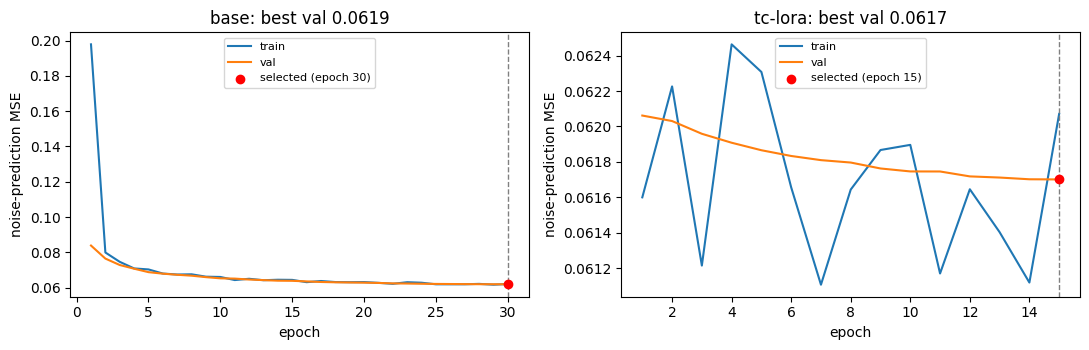

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for a, (name, hist) in zip(ax, [("base", base_hist), ("tc-lora", tc_hist)]):
    ep = [h["epoch"] for h in hist]
    if len(hist) > 1:                      # a reused base.pt has a single point
        a.plot(ep, [h["train"] for h in hist], label="train")
    a.plot(ep, [h["val"] for h in hist], label="val", marker="o" if len(hist) == 1 else None)
    best = min(hist, key=lambda h: h["val"])
    a.axvline(best["epoch"], ls="--", c="grey", lw=1)
    a.scatter([best["epoch"]], [best["val"]], c="red", zorder=5,
              label=f"selected (epoch {best['epoch']})")
    a.set_title(f"{name}: best val {best['val']:.4f}")
    a.set_xlabel("epoch"); a.set_ylabel("noise-prediction MSE"); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Samples — same starting noise, three conditions

Row 1: the base model, same label path as the arm under test. Row 2: TC-LoRA with the
**correct** description. Row 3: TC-LoRA with a **wrong** description (labels shifted by
one). All three start from the same noise, so any difference is the text.

In [14]:
N = 8
y_eval = torch.arange(N, device=DEV) % meta["n_conditions"]
y_wrong = (y_eval + 1) % meta["n_conditions"]
g = torch.Generator(device=DEV).manual_seed(cfg.seed + 1)
X0 = torch.randn(N, *meta["shape"], device=DEV, generator=g)

base_s = ddim_sample(lambda x, t: base_frozen(x, t, COND(y_eval)), N, meta["shape"],
                     cfg.sample_steps, x_init=X0)
tc_s = ddim_sample(lambda x, t: tc(x, t, COND_EMB[y_eval], cond_ids=COND(y_eval)),
                   N, meta["shape"], cfg.sample_steps, x_init=X0)
tc_wrong = ddim_sample(lambda x, t: tc(x, t, COND_EMB[y_wrong], cond_ids=COND(y_eval)),
                       N, meta["shape"], cfg.sample_steps, x_init=X0)
print("sampled:", tuple(base_s.shape), "| NFE per sample:", cfg.sample_steps,
      "| paired: same X0 for all rows")

SAMPLE_TEXT_DIFF = ((tc_s - tc_wrong).flatten(1).norm(dim=1) / tc_s.flatten(1).norm(dim=1)).mean().item()
print(f"mean relative difference between correct-text and wrong-text samples: {SAMPLE_TEXT_DIFF:.1%}")

sampled: (8, 3, 32, 32) | NFE per sample: 50 | paired: same X0 for all rows
mean relative difference between correct-text and wrong-text samples: 12.4%


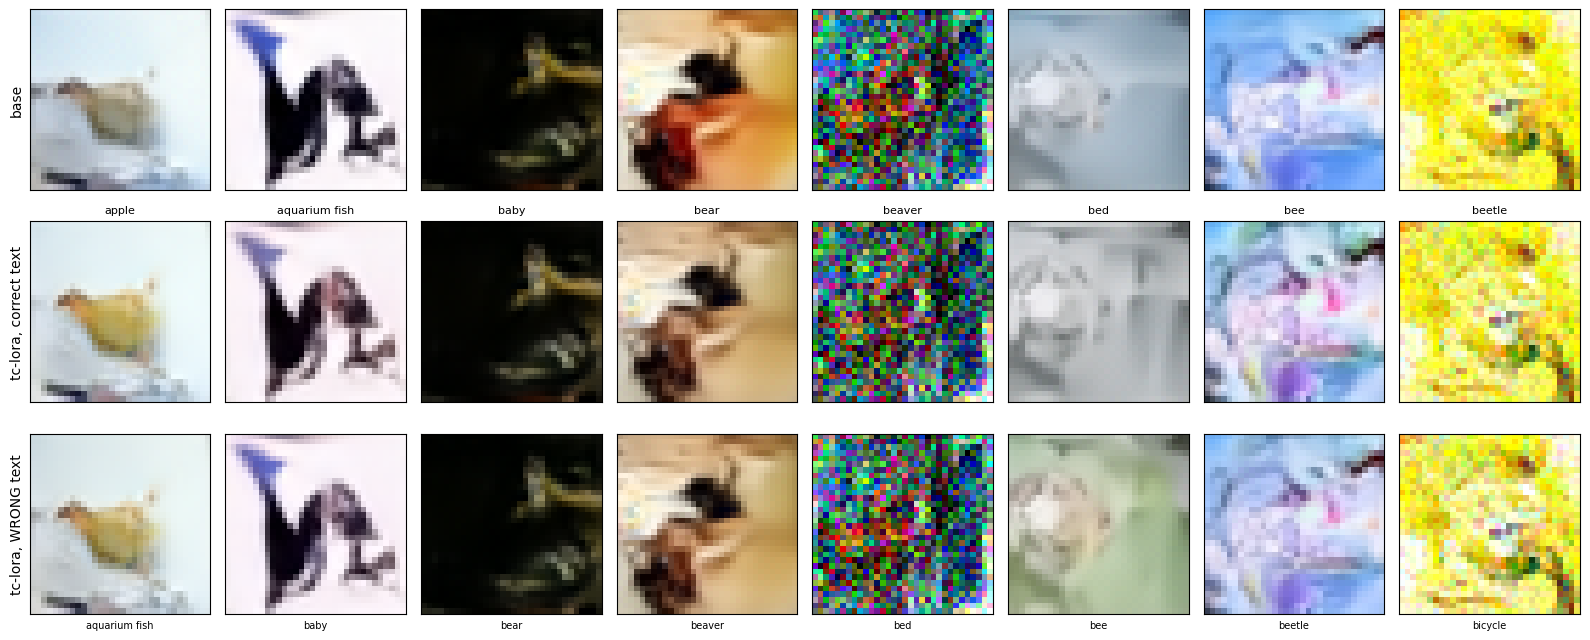

In [15]:
import matplotlib.pyplot as plt

def short(i):
    return meta["cond_text"][int(i)].replace("a photo of a ", "")

fig, axes = plt.subplots(3, N, figsize=(2 * N, 6.6))
rows = [("base", base_s, y_eval), ("tc-lora, correct text", tc_s, y_eval),
        ("tc-lora, WRONG text", tc_wrong, y_wrong)]
for r, (name, s, ys) in enumerate(rows):
    for j in range(N):
        axes[r, j].imshow(((s[j].cpu() + 1) / 2).clamp(0, 1).permute(1, 2, 0).numpy())
        axes[r, j].set_xticks([]); axes[r, j].set_yticks([])
        if r == 1:
            axes[r, j].set_title(short(ys[j]), fontsize=8)
        if r == 2:
            axes[r, j].set_xlabel(short(ys[j]), fontsize=7)
    axes[r, 0].set_ylabel(name, fontsize=10)
plt.tight_layout(); plt.show()

## Denoising trajectory

The same sample at several points along the reverse process, noise on the left and the
finished image on the right. Useful for the appendix and for spotting a sampler that is
diverging rather than converging.

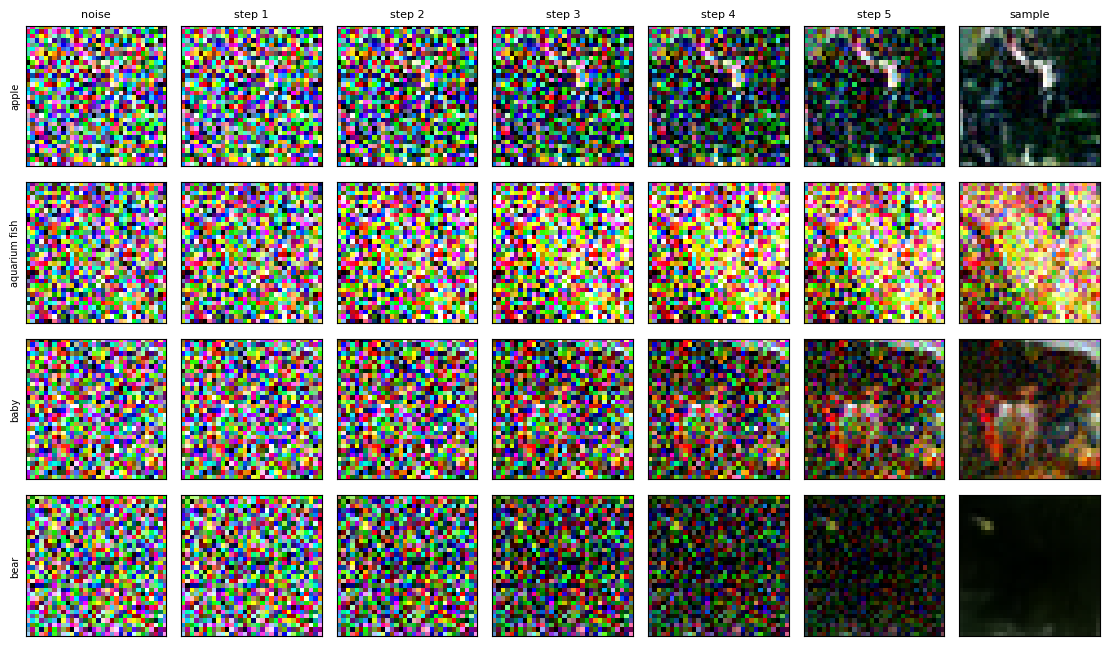

In [16]:
traj_y = y_eval[:4]
_, snaps = ddim_sample(lambda x, t: tc(x, t, COND_EMB[traj_y], cond_ids=COND(traj_y)),
                       4, meta["shape"], cfg.sample_steps, n_snapshots=6)

fig, axes = plt.subplots(4, len(snaps), figsize=(1.6 * len(snaps), 6.6))
for r in range(4):
    for c, s in enumerate(snaps):
        axes[r, c].imshow(((s[r] + 1) / 2).clamp(0, 1).permute(1, 2, 0).numpy())
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
        if r == 0:
            axes[r, c].set_title("noise" if c == 0 else
                                 ("sample" if c == len(snaps) - 1 else f"step {c}"),
                                 fontsize=8)
    axes[r, 0].set_ylabel(meta["cond_text"][int(traj_y[r])].replace("a photo of a ", ""),
                          fontsize=7)
plt.tight_layout(); plt.show()

## FID (optional, needs a GPU)

Section 4.1 asks for a fidelity metric on images. FID is unstable below ~10k samples, so
set `n_fid` accordingly and record the count next to the number. On an A100 this is a few
minutes; skip it while iterating.

In [17]:
n_fid = 10000         # set to 10000 for a reportable number; 0 skips this cell

FID_SCORES = {}

if n_fid:
    # torchmetrics is not preinstalled on Colab, and its FID needs torch-fidelity
    # for the Inception feature extractor.
    import importlib.util, subprocess, sys
    for pkg, mod in [("torchmetrics", "torchmetrics"), ("torch-fidelity", "torch_fidelity")]:
        if importlib.util.find_spec(mod) is None:
            print(f"installing {pkg} ...")
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

    from torchmetrics.image.fid import FrechetInceptionDistance

    def to_uint8(x):
        return ((x.clamp(-1, 1) + 1) * 127.5).round().to(torch.uint8)

    def sample_for(which, y):
        if which == "base":
            return ddim_sample(lambda x, t: base_frozen(x, t, COND(y)),
                               len(y), meta["shape"], cfg.sample_steps)
        return ddim_sample(lambda x, t: tc(x, t, COND_EMB[y], cond_ids=COND(y)),
                           len(y), meta["shape"], cfg.sample_steps)

    for which in ("base", "tclora"):
        fid = FrechetInceptionDistance(feature=2048, normalize=False).to(DEV)

        n_real = 0
        for x, _ in val_loader:
            fid.update(to_uint8(x.to(DEV)), real=True)
            n_real += len(x)

        torch.manual_seed(cfg.seed)
        for start in range(0, n_fid, 100):
            y = torch.arange(start, min(start + 100, n_fid), device=DEV) % meta["n_conditions"]
            fid.update(to_uint8(sample_for(which, y)), real=False)

        FID_SCORES[f"{which}_fid"] = float(fid.compute())
        FID_SCORES["fid_n_real"] = n_real
        FID_SCORES["fid_n_generated"] = n_fid
        print(f"{which} FID {FID_SCORES[f'{which}_fid']:.2f}   "
              f"(real {n_real}, generated {n_fid}, NFE {cfg.sample_steps})")

    if min(FID_SCORES["fid_n_real"], n_fid) < 10000:
        print()
        print("NOTE: FID is biased upward below ~10k samples. Report both counts.")
else:
    print("FID skipped (n_fid = 0)")

installing torchmetrics ...
installing torch-fidelity ...


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 253MB/s]


base FID 80.36   (real 5000, generated 10000, NFE 50)
tclora FID 81.58   (real 5000, generated 10000, NFE 50)

NOTE: FID is biased upward below ~10k samples. Report both counts.


## Manifest

In [18]:
report = {
    "method": "TC-LoRA (reimplementation of arXiv:2510.09561)",
    "modality": "images",
    "code_version": GIT_SHA,
    "config": asdict(cfg),
    "label_path": cfg.label_path,
    "val_matched_base_same_path": VAL_BASE_SAME,     # fixed noise, same examples
    "val_matched_base_true_label": VAL_BASE_LABEL,
    "val_matched_tclora": VAL_TC,
    "val_matched_tclora_wrong_text": VAL_TC_WRONG,
    "val_matched_tclora_wrong_text_per_offset": dict(zip(map(str, WRONG_OFFSETS), VAL_TC_WRONG_EACH)),
    "text_effect_rel": TEXT_EFFECT,
    "text_effect_rel_by_noise_bin": TEXT_EFFECT_BY_BIN,
    "sample_text_diff_rel": SAMPLE_TEXT_DIFF,
    "base_best_val_during_training": min(h["val"] for h in base_hist),
    "tclora_best_val_during_training": min(h["val"] for h in tc_hist),
    "trainable_hypernetwork": tc.n_trainable(),
    "frozen_backbone": N_FROZEN,
    "checkpoint_meta": CKPT_META,
    "adapted_layers": len(tc.adapted),
    "adapter_rel_norm": ADAPTER_REL_NORM,
    "nfe": cfg.sample_steps,
    "clip_fallback": IS_FALLBACK,
    "synthetic_data": bool(meta.get("SYNTHETIC", False)),
    "device": str(DEV),
}
report.update(globals().get("FID_SCORES", {}))

print(json.dumps(report, indent=2))
with open("manifest_tclora_images.json", "w") as f:
    json.dump(report, f, indent=2)

{
  "method": "TC-LoRA (reimplementation of arXiv:2510.09561)",
  "modality": "images",
  "code_version": "1aff1df",
  "config": {
    "seed": 10,
    "split_seed": 10,
    "batch_size": 64,
    "base_epochs": 30,
    "lora_epochs": 15,
    "lr_base": 0.0002,
    "lr_hyper": 0.0001,
    "K": 1000,
    "sample_steps": 50,
    "rank": 4,
    "hyper_width": 256,
    "label_path": false,
    "reuse_base": true,
    "limit": 0
  },
  "label_path": false,
  "val_matched_base_same_path": 0.06206942777633667,
  "val_matched_base_true_label": 0.06189222239255905,
  "val_matched_tclora": 0.061701094174385074,
  "val_matched_tclora_wrong_text": 0.06221853881080946,
  "val_matched_tclora_wrong_text_per_offset": {
    "1": 0.06221756658554077,
    "37": 0.06221621620059013,
    "73": 0.06222183364629746
  },
  "text_effect_rel": 0.008386312161044285,
  "text_effect_rel_by_noise_bin": [
    0.004399084242201311,
    0.010147421693231752,
    0.016530184216696046,
    0.02607371245166013,
    0.03472

## Before reporting any of this

- [ ] FID computed separately with at least 10k samples; this notebook reports validation loss only
- [ ] `clip_fallback: false` in the manifest
- [ ] `base_epochs` and `lora_epochs` at their real values, `limit` at 0
- [ ] `label_path` stated next to every number; the two settings are different experiments
- [ ] `text_effect_rel` reported with its sign and the per-noise-level breakdown; a small or null effect is a reportable result, not a reason to withhold the row
- [ ] Three seeds (`seed`), mean +/- std, with `split_seed` held fixed
- [ ] Parameter counts and NFE next to every number
- [ ] Described as a **reimplementation** of arXiv:2510.09561, not a reproduction, with the scale gap disclosed: the authors train 251M hypernetwork parameters for 3 days on 8x H100